In [1]:
import numpy as np
import pickle, os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print("✅ Libraries loaded")

Device : cpu
✅ Libraries loaded


In [2]:
CLASSES   = ['healthy', 'worn', 'damaged']
N_PER_CLASS = 300   # 300 images per class = 900 total
IMG_SIZE    = 64    # 64×64 pixels

def make_healthy(n):
    """Smooth uniform texture — no defects"""
    imgs = np.random.normal(0.6, 0.05, (n, IMG_SIZE, IMG_SIZE))
    # Add subtle circular part outline
    cx, cy = IMG_SIZE//2, IMG_SIZE//2
    for i in range(n):
        for r in [20, 21]:
            for angle in np.linspace(0, 2*np.pi, 200):
                px = int(cx + r*np.cos(angle))
                py = int(cy + r*np.sin(angle))
                if 0 <= px < IMG_SIZE and 0 <= py < IMG_SIZE:
                    imgs[i, py, px] = 0.85
    return np.clip(imgs, 0, 1)

def make_worn(n):
    """Uneven texture with wear streaks"""
    imgs = np.random.normal(0.45, 0.1, (n, IMG_SIZE, IMG_SIZE))
    for i in range(n):
        # Add 3-5 horizontal wear streaks
        n_streaks = np.random.randint(3, 6)
        for _ in range(n_streaks):
            row = np.random.randint(10, IMG_SIZE-10)
            width = np.random.randint(20, 45)
            start = np.random.randint(5, IMG_SIZE-width)
            imgs[i, row:row+2, start:start+width] = 0.2
    return np.clip(imgs, 0, 1)

def make_damaged(n):
    """Dark patches + cracks — severe damage"""
    imgs = np.random.normal(0.35, 0.12, (n, IMG_SIZE, IMG_SIZE))
    for i in range(n):
        # Add 2-3 dark damage patches
        for _ in range(np.random.randint(2, 4)):
            r = np.random.randint(5, 15)
            c = np.random.randint(5, 15)
            x = np.random.randint(r, IMG_SIZE-r)
            y = np.random.randint(c, IMG_SIZE-c)
            imgs[i, x-r:x+r, y-c:y+c] = np.random.uniform(0.0, 0.15)
        # Add diagonal crack lines
        for k in range(np.random.randint(8, 20)):
            pos = np.random.randint(0, IMG_SIZE-1)
            imgs[i, pos, min(pos+k, IMG_SIZE-1)] = 0.05
    return np.clip(imgs, 0, 1)

# Generate all images
imgs_healthy = make_healthy(N_PER_CLASS)
imgs_worn    = make_worn(N_PER_CLASS)
imgs_damaged = make_damaged(N_PER_CLASS)

X_imgs = np.concatenate([imgs_healthy, imgs_worn, imgs_damaged])
y_imgs = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS + [2]*N_PER_CLASS)

print(f"Images generated: {X_imgs.shape}  → (total, H, W)")
print(f"Labels          : {y_imgs.shape}")

Images generated: (900, 64, 64)  → (total, H, W)
Labels          : (900,)


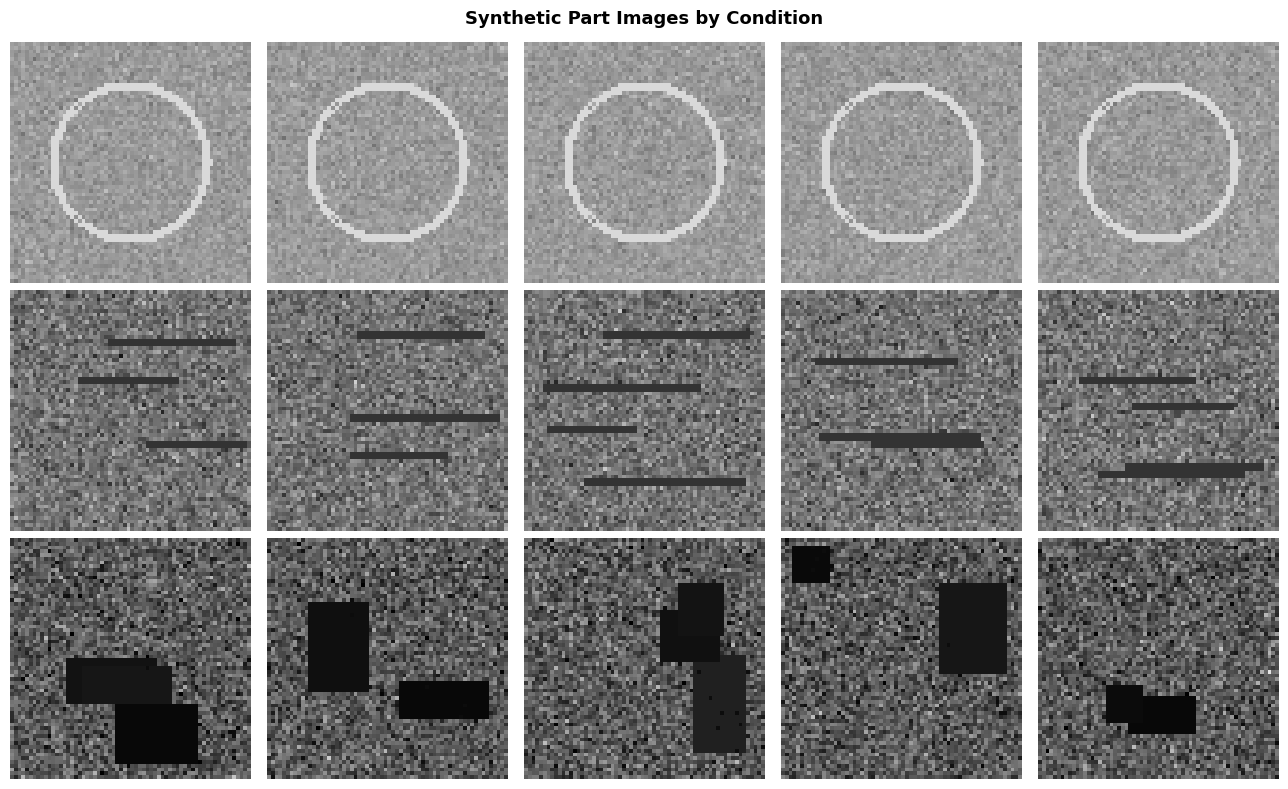

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(13, 8))
sample_imgs = [imgs_healthy, imgs_worn, imgs_damaged]
titles = ['Healthy', 'Worn', 'Damaged']
colors = ['#2a9d8f', '#d4a017', '#e63946']

for row, (imgs, title, color) in \
        enumerate(zip(sample_imgs, titles, colors)):
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(imgs[col*10], cmap='gray',
                  vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(title, color=color,
                          fontsize=12, fontweight='bold')

plt.suptitle('Synthetic Part Images by Condition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot8_sample_images.png', dpi=120)
plt.show()

In [4]:
# CNN expects (batch, channels, H, W)
# Our images are grayscale → repeat to 3 channels for ResNet
X_tensor = torch.tensor(X_imgs, dtype=torch.float32)
X_tensor = X_tensor.unsqueeze(1).repeat(1, 3, 1, 1)  # → (900, 3, 64, 64)
y_tensor = torch.tensor(y_imgs, dtype=torch.long)

# Normalise using ImageNet mean/std (required for pretrained ResNet)
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)
X_tensor = torch.stack([normalize(img) for img in X_tensor])

dataset    = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size],
                    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

print(f"Tensor shape : {X_tensor.shape}  → (samples, 3, 64, 64)")
print(f"Train samples: {train_size} | Val samples: {val_size}")

Tensor shape : torch.Size([900, 3, 64, 64])  → (samples, 3, 64, 64)
Train samples: 720 | Val samples: 180


In [5]:
# Load ResNet18 pretrained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers — we only train the final classifier
for param in model.parameters():
    param.requires_grad = False

# Replace final layer: ImageNet has 1000 classes, we have 3
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 3)   # 3 output classes
)

model = model.to(device)

# Only the new fc layer trains
trainable = sum(p.numel() for p in model.parameters()
                if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}  (only final layer)")
print(f"Frozen params    : {total-trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\abhyu/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:12<00:00, 3.78MB/s]


Total params     : 11,209,539
Trainable params : 33,027  (only final layer)
Frozen params    : 11,176,512


In [6]:
criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

EPOCHS = 15
train_losses, val_losses = [], []
val_accs = []
best_val_acc  = 0.0

print(f"Training for {EPOCHS} epochs...\n")

for epoch in range(EPOCHS):
    # ── Train ──
    model.train()
    batch_losses, correct, total = [], 0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimiser.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        optimiser.step()
        batch_losses.append(loss.item())
        correct += (out.argmax(1) == y_b).sum().item()
        total   += y_b.size(0)

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validate ──
    model.eval()
    val_batch_losses, v_correct, v_total = [], 0, 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out  = model(X_b)
            val_batch_losses.append(criterion(out, y_b).item())
            v_correct += (out.argmax(1) == y_b).sum().item()
            v_total   += y_b.size(0)

    val_loss = np.mean(val_batch_losses)
    val_acc  = v_correct / v_total * 100
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../models/cnn_best.pt')
        saved = "✅"
    else:
        saved = ""

    print(f"Epoch {epoch+1:02d}/{EPOCHS} │ Loss: {train_loss:.3f} │ "
          f"Val Loss: {val_loss:.3f} │ Val Acc: {val_acc:.1f}%  {saved}")

print(f"\n✅ Best val accuracy: {best_val_acc:.1f}%")

Training for 15 epochs...

Epoch 01/15 │ Loss: 0.428 │ Val Loss: 0.294 │ Val Acc: 90.0%  ✅
Epoch 02/15 │ Loss: 0.085 │ Val Loss: 0.063 │ Val Acc: 100.0%  ✅
Epoch 03/15 │ Loss: 0.056 │ Val Loss: 0.011 │ Val Acc: 100.0%  
Epoch 04/15 │ Loss: 0.032 │ Val Loss: 0.021 │ Val Acc: 100.0%  
Epoch 05/15 │ Loss: 0.028 │ Val Loss: 0.006 │ Val Acc: 100.0%  
Epoch 06/15 │ Loss: 0.015 │ Val Loss: 0.004 │ Val Acc: 100.0%  
Epoch 07/15 │ Loss: 0.017 │ Val Loss: 0.003 │ Val Acc: 100.0%  
Epoch 08/15 │ Loss: 0.021 │ Val Loss: 0.008 │ Val Acc: 100.0%  
Epoch 09/15 │ Loss: 0.036 │ Val Loss: 0.010 │ Val Acc: 100.0%  
Epoch 10/15 │ Loss: 0.010 │ Val Loss: 0.003 │ Val Acc: 100.0%  
Epoch 11/15 │ Loss: 0.006 │ Val Loss: 0.002 │ Val Acc: 100.0%  
Epoch 12/15 │ Loss: 0.020 │ Val Loss: 0.002 │ Val Acc: 100.0%  
Epoch 13/15 │ Loss: 0.026 │ Val Loss: 0.002 │ Val Acc: 100.0%  
Epoch 14/15 │ Loss: 0.031 │ Val Loss: 0.004 │ Val Acc: 100.0%  
Epoch 15/15 │ Loss: 0.017 │ Val Loss: 0.003 │ Val Acc: 100.0%  

✅ Best val 

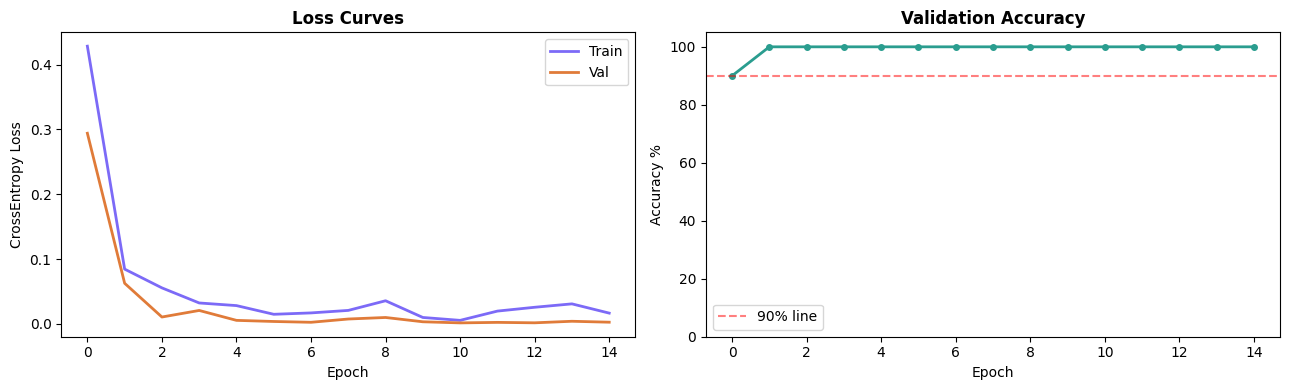

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(train_losses, label='Train', color='#7c6af7', linewidth=2)
axes[0].plot(val_losses,   label='Val',   color='#e07b39', linewidth=2)
axes[0].set_title('Loss Curves', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()

axes[1].plot(val_accs, color='#2a9d8f', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_ylim([0, 105])
axes[1].axhline(90, color='red', linestyle='--', alpha=0.5, label='90% line')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/plot9_cnn_curves.png', dpi=120)
plt.show()

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        63
        worn       1.00      1.00      1.00        57
     damaged       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



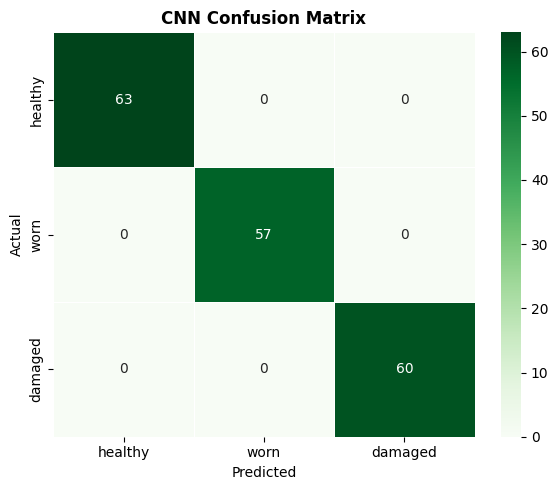

In [8]:
model.load_state_dict(torch.load('../models/cnn_best.pt',
                                  map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        out = model(X_b.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y_b.numpy())

print(classification_report(all_true, all_preds,
      target_names=CLASSES))

cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax, linewidths=0.5)
ax.set_title('CNN Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../data/plot10_cnn_confusion.png', dpi=120)
plt.show()

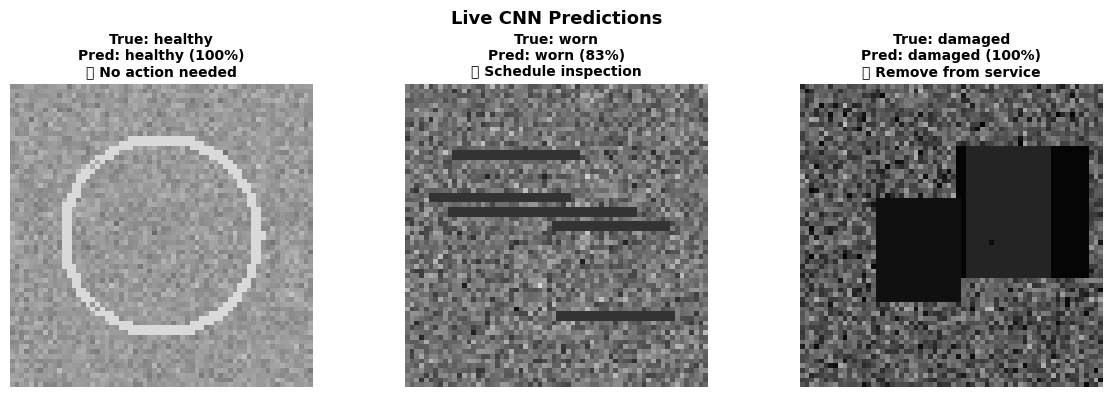

In [9]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

def predict_image(img_array):
    """Takes a 64x64 numpy array, returns condition + confidence."""
    t = torch.tensor(img_array, dtype=torch.float32)
    t = t.unsqueeze(0).repeat(3, 1, 1)
    t = normalize(t).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = model(t)
        proba = torch.nn.functional.softmax(out, dim=1)[0]
    pred  = proba.argmax().item()
    conf  = proba[pred].item() * 100
    return CLASSES[pred], conf, proba.cpu().numpy()

# Predict one of each class
test_samples = [
    (imgs_healthy[5],  'healthy'),
    (imgs_worn[5],     'worn'),
    (imgs_damaged[5],  'damaged'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
actions = {
    'healthy' : "✅ No action needed",
    'worn'    : "🟡 Schedule inspection",
    'damaged' : "🔴 Remove from service"
}

for i, (img, true_label) in enumerate(test_samples):
    pred, conf, proba = predict_image(img)
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred} ({conf:.0f}%)\n{actions[pred]}",
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Live CNN Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plot11_live_predictions.png', dpi=120)
plt.show()

In [10]:
import json
from sklearn.metrics import accuracy_score

cnn_acc = accuracy_score(all_true, all_preds)

cnn_meta = {
    'classes'      : CLASSES,
    'accuracy'     : round(cnn_acc * 100, 2),
    'best_val_acc' : round(best_val_acc, 2),
    'img_size'     : IMG_SIZE,
    'architecture' : 'ResNet18 (transfer learning)',
    'epochs'       : EPOCHS,
}
with open('../models/cnn_metadata.json', 'w') as f:
    json.dump(cnn_meta, f, indent=2)

print("✅ Phase 4 complete! Saved:")
print("   models/cnn_best.pt")
print("   models/cnn_metadata.json")
print(f"\n📊 CNN accuracy : {cnn_acc*100:.1f}%")
print(f"   Architecture : ResNet18 transfer learning")
print(f"   Classes      : {CLASSES}")
print(f"\n🚀 Ready for Phase 5 — Fusion model!")

✅ Phase 4 complete! Saved:
   models/cnn_best.pt
   models/cnn_metadata.json

📊 CNN accuracy : 100.0%
   Architecture : ResNet18 transfer learning
   Classes      : ['healthy', 'worn', 'damaged']

🚀 Ready for Phase 5 — Fusion model!
